In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
data1=np.linspace(0,1,10)
data2=[0.5+0.5*np.cos(np.pi*((i-0.5)/10)) for i in range(1,11)]
datas=[data1, data2]
data1=np.array(data1)
data2=np.array(data2)
datas=np.array(datas)
R_matrix=np.zeros([len(data2), len(data2)])
x=np.linspace(0,1,1000)

# IMSE Calculation

In [2]:
def R(x, theta=0.1):
    return np.exp(-((x**2)/(theta**2)))

def r(x, data):
    x_R=x-data
    return R(x_R)

def s(x, R_matrix,  data):
    return np.sqrt(1-r(x, data).T@np.linalg.inv(R_matrix)@r(x, data))

In [3]:
def IMSE(datas,x):
    if len(datas.shape)==1:
        datas=datas.reshape(1,-1)
    output=[]
    del_x=x[1]-x[0]
    for data in datas:
        areas=np.zeros([len(data), len(data)])
        ys=[]
        r_matrix=[]
        R_matrix=[]
        for i in x:
            r_x=r(np.array([i]), data)
            r_x=r_x.reshape(-1,1)
            ys.append(r_x@r_x.T)
        for j in data:
            R_matrix.append(r(np.array(j), data))
        R_matrix=np.array(R_matrix)
        inverse=np.linalg.inv(R_matrix)  
        ys=np.array(ys)
    
        for index in range(len(ys)-1):
            areas=areas+(1/2)*(ys[index]+ys[index+1])*del_x
        output.append(1-np.trace(inverse@areas))
    
    return np.array(output)
imse=IMSE(datas, x)       

# RMSE for equispaced and Chevyshevs points

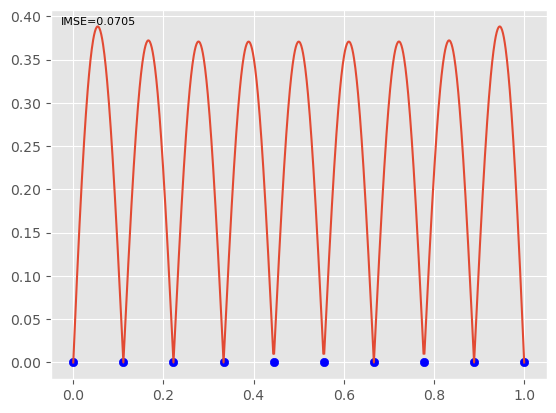

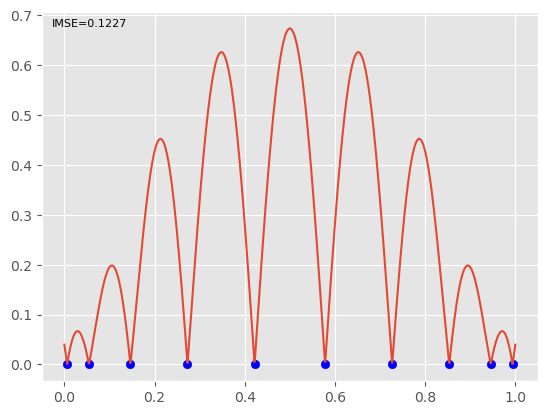

In [4]:

for index, data in enumerate(datas):
    for i in range(len(data)):
        for j in range(len(data)):
            R_matrix[i,j]=R(data[i]-data[j])

    s_=[]
    for i in x:
        s_.append(s(i, R_matrix, data))
    fig, ax = plt.subplots()
    
    ax.plot(x,s_)
    ax.text(
        0.02, 0.98,
        f"IMSE={imse[index]:.4f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8

    )
    ax.scatter(data, [0 for i in range(len(data))], color="b")
    

## Gradieant of IMSE

In [5]:
def Grad_IMSE(data, x, epsilon=0.01):
    output=[]
    IMSE_k=IMSE(data, x)
    for index, element in enumerate(data):
        edited_data_post=data.copy()
        edited_data_pre=data.copy()
        edited_data_post[index]=element+epsilon
        edited_data_pre[index]=element-epsilon
        IMSE_post=IMSE(edited_data_post, x)
        IMSE_pre=IMSE(edited_data_pre, x)
        possible_gradiant=(IMSE_post-IMSE_pre)/(2*epsilon)

        if (element == 0) and (possible_gradiant>0):
            output.append(0)
        elif (element == 1) and (possible_gradiant<0):
            output.append(0)
        else: 
            output.append(possible_gradiant)
    #grad_post=(IMSE_post-IMSE_k)/epsilon
    #grad_pre=(IMSE_k-IMSE_pre)/epsilon
    return (np.array(output)).reshape(-1,)

In [6]:
print(Grad_IMSE(data1, x))

[-3.73098968e-01 -1.43716361e-02 -1.23732459e-04  1.12901396e-04
  1.78941561e-05 -1.78941562e-05 -1.12901396e-04  1.23732459e-04
  1.43716361e-02  3.73098968e-01]


In [7]:
def H_k(rho_k, s_k, y_k, H):
    s_k=s_k.reshape(1, -1)
    y_k=y_k.reshape(1, -1)
    length=len(H)
    return (np.eye(length)-rho_k*s_k.T@y_k)@H@(np.eye(length)-rho_k*y_k.T@s_k)+rho_k*s_k.T@s_k

## BFGS

In [8]:
def BFGS(data1, x, epsilon=0.01, learning_rate=0.01, stopping=1e-7, num_iti=10000, Display=False):
    epsilon=0.01
    learning_rate=0.01
    H=np.eye(len(data1))
    grad=Grad_IMSE(data1, x, epsilon)
    stopping=1e-7
    s_k=data1
    D_old=data1.copy()
    num_iti=10000
    for iti in range(num_iti):
        p_k=-H@grad
        D_new=np.clip(D_old+learning_rate*p_k, 0, 1)
        s_k=D_new-D_old
    
        if np.max(np.abs(s_k))<stopping:
            print(f"Stopping after {iti} itirations")
            print(f"New Data={D_new}")
            break
        y_k=Grad_IMSE(D_new, x, epsilon)-grad
        curvature=(y_k@s_k)
        if curvature>1e-12:        
            rho_k=1/curvature
            H=H_k(rho_k, s_k, y_k, H)
        grad=Grad_IMSE(D_new, x, epsilon)
        D_old=D_new
        if Display:
            if iti%10==0:
                print(f"Done with itiration: {iti}")
    return D_new



In [9]:
new_data1=BFGS(data1, x, learning_rate=0.1, num_iti=1000)


Stopping after 777 itirations
New Data=[0.04493799 0.14374696 0.24549857 0.34730014 0.4490998  0.55090114
 0.65269987 0.75450145 0.85625394 0.95506152]


In [10]:
optimal_IMSE=IMSE(new_data1, x)
optimal_IMSE

array([0.04957327])

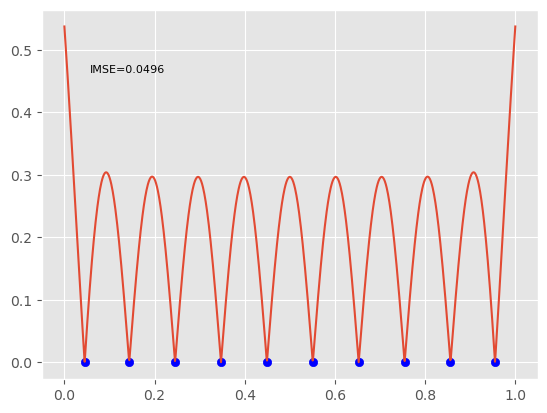

In [11]:
for i in range(len(new_data1)):
    for j in range(len(new_data1)):
        R_matrix[i,j]=R(new_data1[i]-new_data1[j])

s_=[]
for i in x:
    s_.append(s(i, R_matrix, new_data1))
fig2, ax2 = plt.subplots()

ax2.plot(x,s_)
ax2.text(
    0.02, 0.8,
    f"IMSE={optimal_IMSE[0]:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8

)
ax2.scatter(new_data1, [0 for i in range(len(new_data1))], color="b")

## BFGS through Scipy

In [12]:
from scipy.optimize import minimize

In [13]:
def objective_IMSE(data, x):
    D=np.asarray(data, dtype=float)
    imse_value=IMSE(D, x)
    return float(np.asarray(imse_value).squeeze())
    

In [16]:
D0=data1.copy()
bounds=[(0,1)]*len(D0)

In [18]:
result=minimize(
    fun = objective_IMSE,
    x0=D0,
    args=(x, ),
    method="L-BFGS-B",
    jac="3-point",
    bounds=bounds,
    options={
        "finite_diff_rel_step": 1e-4,
        "ftol": 1e-12,
        "gtol": 1e-7,
        "maxiter": 1000,
        "maxls": 40,
        "maxcor": 10,
    }
)


print("Success:", result.success)
print("Reason for stopping:", result.message)
print("Optimal design:", result.x)
print("Optimal IMSE:", result.fun)
print("Iterations:", result.nit)
print("Function evaluations:", result.nfev)

Success: True
Reason for stopping: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Optimal design: [0.04467708 0.14357196 0.24537446 0.34722502 0.449075   0.550925
 0.65277497 0.75462553 0.85642803 0.95532289]
Optimal IMSE: 0.04957239538216596
Iterations: 9
Function evaluations: 252


## Optimum Points for MMSE

In [35]:
def MMSE(datas, x):
    if len(datas.shape)==1:
        datas=datas.reshape(1,-1)
    #output=[]
    #del_x=x[1]-x[0]
    for data in datas:
        #areas=np.zeros([len(data), len(data)])
        #ys=[]
        r_matrix=[]
        R_matrix=[]
        for i in x:
            r_x=r(np.array([i]), data)
            r_matrix.append(r_x)
            #r_x=r_x.reshape(-1,1)
            #ys.append(r_x@r_x.T)
        for j in data:
            R_matrix.append(r(np.array(j), data))
        r_matrix=np.asarray(r_matrix)
        R_matrix=np.array(R_matrix+1e-10*np.eye(len(R_matrix)))
        inverse=np.linalg.solve(R_matrix, np.eye(len(R_matrix)))  
    return np.max(np.diag(1-r_matrix@inverse@r_matrix.T))
        #ys=np.array(ys)

In [40]:
D0=data1.copy()
result_MMSE=minimize(
    fun = MMSE,
    x0=D0,
    args=(x, ),
    method="L-BFGS-B",
    jac="3-point",
    bounds=bounds,
    options={
        "finite_diff_rel_step": 1e-4,
        "ftol": 1e-12,
        "gtol": 1e-7,
        "maxiter": 1000,
        "maxls": 40,
        "maxcor": 10,
    }
)


print("Success:", result_MMSE.success)
print("Reason for stopping:", result_MMSE.message)
print("Optimal design:", result_MMSE.x)
print("Optimal MMSE:", result_MMSE.fun)
print("Iterations:", result_MMSE.nit)
print("Function evaluations:", result_MMSE.nfev)

Success: True
Reason for stopping: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Optimal design: [7.22576091e-04 1.09133506e-01 2.20808572e-01 3.32392048e-01
 4.43971708e-01 5.55529384e-01 6.67096875e-01 7.78630405e-01
 8.89899979e-01 9.98425512e-01]
Optimal MMSE: 0.14014223791575464
Iterations: 47
Function evaluations: 2541


In [41]:
MMSE(data1, x)

0.15070939497142932